In [1]:
from google.cloud import bigquery
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
check_ror_null = client.query(f"""
                                SELECT dfg_inst_id, ror_id, inst_name
                                FROM `subugoe-collaborative.openbib.kb_inst_lookup` AS kba, UNNEST(current_sectors) AS sector
                                JOIN `subugoe-collaborative.resources.inst_with_federal_state` AS fs
                                  ON fs.dfg_inst_id = kba.dfg_instituts_id
                                WHERE federal_state = 'Niedersachsen' 
                                  AND ror_id IS NULL 
                                  AND sector IN ('fh', 'uni')
                              """).to_dataframe()

In [5]:
check_ror_null

,dfg_inst_id,ror_id,inst_name


#### Wichtig: Universitätsmedizin Göttingen wird in GERIT und in der Bielefelder Institutionskodierung zur Universität Göttingen gezählt!

ROR UMG: https://ror.org/021ft0n22

ROR GAU: https://ror.org/01y9bpm73

In [6]:
oal_inst_lower_saxony_raw = client.query(f"""
                            SELECT DISTINCT 
                                kb.id AS kb_id, 
                                oal.id AS oal_id, 
                                kb.source AS kb_source, 
                                oal.source AS oal_source,
                                kb.inst_name AS kb_name,
                                oal.inst_name AS oal_name,
                                ARRAY_TO_STRING(kb.current_sectors, ',') AS kb_sectors,
                                ARRAY_TO_STRING(oal.current_sectors, ',') AS oal_sectors
                            FROM (
                                SELECT o.id, current_sectors, federal_states.inst_name, 'KB' AS source
                                FROM `subugoe-collaborative.openbib.kb_a_addr_inst` AS inst
                                JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb_inst
                                  ON inst.inst_id_top = kb_inst.inst_id
                                JOIN `subugoe-collaborative.resources.inst_with_federal_state` AS federal_states
                                  ON CASE
                                        WHEN kb_inst.inst_id = 621 THEN 'https://ror.org/03m2kj587'
                                        ELSE kb_inst.ror 
                                     END = CONCAT('https://ror.org/', federal_states.ror_id)
                                JOIN `subugoe-collaborative.openalex.works` AS o
                                    ON inst.openalex_id = o.id
                                WHERE publication_year BETWEEN 2020 AND 2024 
                                  AND type='article' 
                                  AND federal_states.federal_state = 'Niedersachsen'
                            ) AS kb
                            FULL OUTER JOIN (
                              SELECT o.id, current_sectors, federal_states.inst_name, 'OAL' AS source
                                FROM (
                                  SELECT oal.id, 
                                         CASE 
                                          WHEN inst.ror = 'https://ror.org/021ft0n22' THEN 'https://ror.org/01y9bpm73'
                                          ELSE inst.ror
                                         END AS ror
                                  FROM `subugoe-collaborative.openalex.works` AS oal, UNNEST(authorships) AS aut, UNNEST(aut.institutions) AS inst
                                  WHERE publication_year BETWEEN 2020 AND 2024 
                                  AND oal.type='article' 
                                ) AS o
                                JOIN `subugoe-collaborative.resources.inst_with_federal_state` AS federal_states
                                    ON o.ror = CONCAT('https://ror.org/', federal_states.ror_id)
                                LEFT JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb_inst
                                    ON kb_inst.ror = CONCAT('https://ror.org/', federal_states.ror_id)
                                WHERE federal_states.federal_state = 'Niedersachsen'
                            ) AS oal
                              ON kb.id = oal.id
                            """).to_dataframe()

In [7]:
oal_inst_lower_saxony = oal_inst_lower_saxony_raw[
    (oal_inst_lower_saxony_raw['kb_sectors'].str.contains('uni')) 
    | (oal_inst_lower_saxony_raw['kb_sectors'].str.contains('fh(?!g)', regex=True))
    | (oal_inst_lower_saxony_raw['oal_sectors'].str.contains('uni'))
    | (oal_inst_lower_saxony_raw['oal_sectors'].str.contains('fh(?!g)', regex=True))
]

In [8]:
oal_inst_lower_saxony

,kb_id,oal_id,kb_source,oal_source,kb_name,oal_name,kb_sectors,oal_sectors
6,https://openalex.org/W4309740956,https://openalex.org/W4309740956,KB,OAL,Deutsches Institut für Lebensmitteltechnik e.V.,Hochschule Osnabrück,ev,fh
9,https://openalex.org/W4402783630,https://openalex.org/W4402783630,KB,OAL,PFH Private Hochschule Göttingen,PFH Private Hochschule Göttingen,fh,fh
11,https://openalex.org/W3028245168,https://openalex.org/W3028245168,KB,OAL,Max-Planck-Institut zur Erforschung multirelig...,Georg-August-Universität Göttingen,mpg,uni
13,https://openalex.org/W3132913110,https://openalex.org/W3132913110,KB,OAL,Nordwestdeutsche Forstliche Versuchsanstalt,Georg-August-Universität Göttingen,res-l,uni
14,https://openalex.org/W4220724224,https://openalex.org/W4220724224,KB,OAL,Fraunhofer-Institut für Holzforschung - Wilhel...,Technische Universität Braunschweig,fhg,uni
...,...,...,...,...,...,...,...,...
116236,https://openalex.org/W3210146342,https://openalex.org/W3210146342,KB,OAL,Universität Osnabrück,Universität Osnabrück,uni,uni
116237,https://openalex.org/W3015068359,https://openalex.org/W3015068359,KB,OAL,Universität Osnabrück,Universität Osnabrück,uni,uni
116238,https://openalex.org/W3034175744,https://openalex.org/W3034175744,KB,OAL,Universität Osnabrück,Universität Osnabrück,uni,uni
116239,https://openalex.org/W3207363777,https://openalex.org/W3207363777,KB,OAL,Universität Osnabrück,Universität Osnabrück,uni,uni


In [9]:
oal_inst_lower_saxony.kb_source.count()

88818

In [10]:
oal_inst_lower_saxony.oal_source.count()

90797

In [11]:
kb_list = oal_inst_lower_saxony.groupby('kb_id')['kb_name'].apply(set).reset_index()

In [12]:
oal_list = oal_inst_lower_saxony.groupby('oal_id')['oal_name'].apply(set).reset_index()

In [13]:
inst_list = pd.merge(kb_list, oal_list, left_on='kb_id', right_on='oal_id', how='outer')

In [14]:
inst_list['kb_name'] = inst_list['kb_name'].fillna('').apply(set)
inst_list['oal_name'] = inst_list['oal_name'].fillna('').apply(set)

inst_list['in_oal_missing'] = list(inst_list['kb_name'] - inst_list['oal_name'])
inst_list['in_kb_missing'] = list(inst_list['oal_name'] - inst_list['kb_name'])

inst_list['kb_count'] = inst_list.kb_name.str.len()
inst_list['oal_count'] = inst_list.oal_name.str.len()

In [15]:
inst_list[inst_list.in_oal_missing.str.len() > 0]

,kb_id,kb_name,oal_id,oal_name,in_oal_missing,in_kb_missing,kb_count,oal_count
6,https://openalex.org/W173619620,{Leuphana Universität Lüneburg},NaN,{},{Leuphana Universität Lüneburg},{},1,0
22,https://openalex.org/W2340624100,{Gottfried Wilhelm Leibniz Universität Hannover},https://openalex.org/W2340624100,{Helmholtz-Zentrum für Infektionsforschung (HZI)},{Gottfried Wilhelm Leibniz Universität Hannover},{Helmholtz-Zentrum für Infektionsforschung (HZI)},1,1
24,https://openalex.org/W2396187297,{Gottfried Wilhelm Leibniz Universität Hannover},NaN,{},{Gottfried Wilhelm Leibniz Universität Hannover},{},1,0
31,https://openalex.org/W2550770972,{Georg-August-Universität Göttingen},https://openalex.org/W2550770972,"{Technische Informationsbibliothek (TIB), Gese...",{Georg-August-Universität Göttingen},{Gesellschaft für wissenschaftliche Datenverar...,1,2
49,https://openalex.org/W2757461179,{Georg-August-Universität Göttingen},NaN,{},{Georg-August-Universität Göttingen},{},1,0
...,...,...,...,...,...,...,...,...
66200,https://openalex.org/W4407893398,"{Georg-August-Universität Göttingen, Gesellsch...",https://openalex.org/W4407893398,{Georg-August-Universität Göttingen},{Gesellschaft für wissenschaftliche Datenverar...,{},2,1
66209,https://openalex.org/W4408145603,{Universität Osnabrück},NaN,{},{Universität Osnabrück},{},1,0
66239,https://openalex.org/W4408795219,{Physikalisch-Technische Bundesanstalt (PTB)},https://openalex.org/W4408795219,{Technische Universität Braunschweig},{Physikalisch-Technische Bundesanstalt (PTB)},{Technische Universität Braunschweig},1,1
66264,https://openalex.org/W4410358849,{Universität Osnabrück},NaN,{},{Universität Osnabrück},{},1,0


In [16]:
inst_list[inst_list.in_kb_missing.str.len() > 0]

,kb_id,kb_name,oal_id,oal_name,in_oal_missing,in_kb_missing,kb_count,oal_count
12,https://openalex.org/W192689753,{Gottfried Wilhelm Leibniz Universität Hannover},https://openalex.org/W192689753,{Gottfried Wilhelm Leibniz Universität Hannove...,{},{Leibniz-Fachhochschule},1,2
22,https://openalex.org/W2340624100,{Gottfried Wilhelm Leibniz Universität Hannover},https://openalex.org/W2340624100,{Helmholtz-Zentrum für Infektionsforschung (HZI)},{Gottfried Wilhelm Leibniz Universität Hannover},{Helmholtz-Zentrum für Infektionsforschung (HZI)},1,1
25,https://openalex.org/W2462619985,{Medizinische Hochschule Hannover (MHH)},https://openalex.org/W2462619985,"{Georg-August-Universität Göttingen, Medizinis...",{},{Georg-August-Universität Göttingen},1,2
31,https://openalex.org/W2550770972,{Georg-August-Universität Göttingen},https://openalex.org/W2550770972,"{Technische Informationsbibliothek (TIB), Gese...",{Georg-August-Universität Göttingen},{Gesellschaft für wissenschaftliche Datenverar...,1,2
43,https://openalex.org/W2732479381,{Georg-August-Universität Göttingen},https://openalex.org/W2732479381,"{Georg-August-Universität Göttingen, Institut ...",{},{Institut für Nanophotonik Göttingen e.V. (IFN...,1,2
...,...,...,...,...,...,...,...,...
69987,NaN,{},https://openalex.org/W4413640333,{Universität Osnabrück},{},{Universität Osnabrück},0,1
69988,NaN,{},https://openalex.org/W4414084594,"{Medizinische Hochschule Hannover (MHH), Gottf...",{},"{Medizinische Hochschule Hannover (MHH), Gottf...",0,2
69989,NaN,{},https://openalex.org/W4414360822,{Georg-August-Universität Göttingen},{},{Georg-August-Universität Göttingen},0,1
69990,NaN,{},https://openalex.org/W4414360888,{Gottfried Wilhelm Leibniz Universität Hannover},{},{Gottfried Wilhelm Leibniz Universität Hannover},0,1


In [17]:
inst_list.kb_count.sum()

75475

In [18]:
inst_list.oal_count.sum()

76819

In [19]:
inst_list.kb_count.mean()

1.07833752428849

In [20]:
inst_list.oal_count.mean()

1.0975397188250087

In [21]:
kb_c = inst_list.explode('kb_name').groupby(['kb_name'])['kb_id'].count().reset_index().rename(columns={'kb_id': 'n_kb'})

In [22]:
oal_c = inst_list.explode('oal_name').groupby(['oal_name'])['oal_id'].count().reset_index().rename(columns={'oal_id': 'n_oal'})

In [23]:
table_c = pd.merge(kb_c, oal_c, left_on='kb_name', right_on='oal_name', how='outer')

In [24]:
table_c['n_kb'] = table_c['n_kb'].fillna(0)
table_c['n_oal'] = table_c['n_oal'].fillna(0)

table_c['n_kb'] = table_c['n_kb'].astype(int)
table_c['n_oal'] = table_c['n_oal'].astype(int)

In [25]:
filter_uni_fh = client.query(f"""
                                SELECT dfg_inst_id, ror_id, inst_name
                                FROM `subugoe-collaborative.openbib.kb_inst_lookup` AS kba, UNNEST(current_sectors) AS sector
                                JOIN `subugoe-collaborative.resources.inst_with_federal_state` AS fs
                                  ON fs.dfg_inst_id = kba.dfg_instituts_id
                                WHERE federal_state = 'Niedersachsen' 
                                  AND sector IN ('fh', 'uni')
                              """).to_dataframe()

In [26]:
inst_tab = pd.merge(table_c, filter_uni_fh, how='right', left_on='oal_name', right_on='inst_name')
inst_tab['difference'] = inst_tab['n_kb'] - inst_tab['n_oal']

In [27]:
inst_tab[['inst_name', 'ror_id', 'n_kb', 'n_oal', 'difference']]

,inst_name,ror_id,n_kb,n_oal,difference
0,Carl von Ossietzky Universität Oldenburg,033n9gh91,5720,5859,-139
1,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,02vvvm705,324,331,-7
2,Universität Osnabrück,04qmmjx98,2999,3098,-99
3,Ostfalia Hochschule für angewandte Wissenschaften,01bk10867,396,407,-11
4,Gottfried Wilhelm Leibniz Universität Hannover,0304hq317,11418,10972,446
5,Hochschule Hannover,03m2kj587,78,139,-61
6,Medizinische Hochschule Hannover (MHH),00f2yqf98,13128,13205,-77
7,Georg-August-Universität Göttingen,01y9bpm73,19053,19612,-559
8,Fachhochschule für die Wirtschaft Hannover (FHDW),03z6vda50,20,27,-7
9,Technische Universität Braunschweig,010nsgg66,7953,8071,-118


In [28]:
inst_tab[['inst_name', 'ror_id', 'n_kb', 'n_oal', 'difference']].to_csv('../data/inst_tab_sep25.csv', sep=',', index=False)

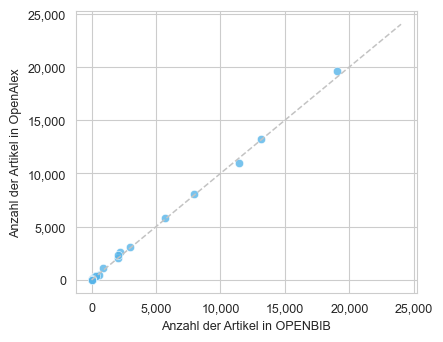

In [29]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

plt.grid(True)

t = 1.25

x = [x for x in range(0, int(inst_tab.n_oal.max() * t), 1000)]
y = x

sns.scatterplot(data=inst_tab, 
                x='n_kb', 
                y='n_oal',
                color='#56B4E9',
                alpha=0.8)

sns.lineplot(x=x, 
             y=y, 
             color='#c3c3c3', 
             linestyle='dashed', 
             linewidth=1.1,
             alpha=1)

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set(xlabel='Anzahl der Artikel in OPENBIB', ylabel='Anzahl der Artikel in OpenAlex')

plt.tight_layout()
plt.show()

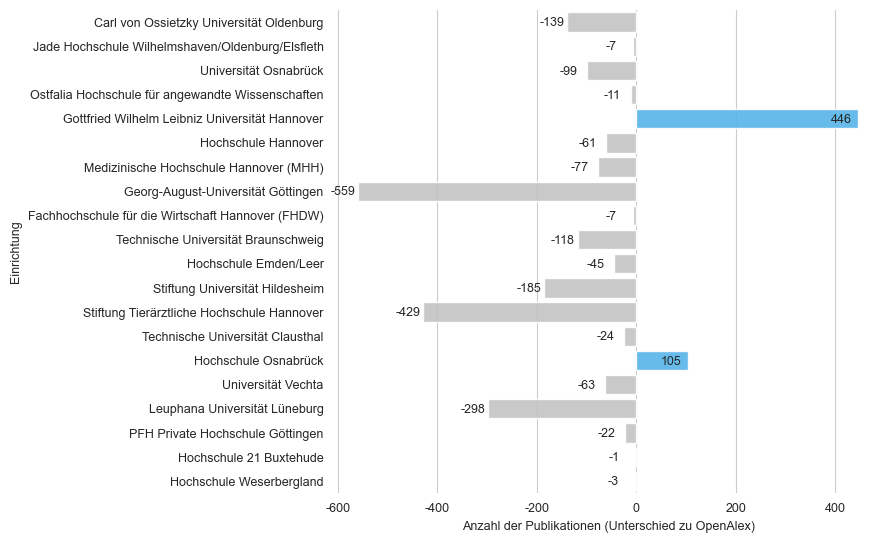

In [33]:
fig, ax = plt.subplots(figsize=(9,5.5))
plt.box(False)

change_color = ['#c3c3c3' if (x < 0) else '#56B4E9' for x in inst_tab.difference]

sns.barplot(data=inst_tab, 
            x='difference', 
            y='inst_name', 
            orient='h',
            saturation=1,
            palette=change_color,
            hue='inst_name',
            alpha=0.9,
            zorder=3,
            errorbar=None)

for idx, row in inst_tab.iterrows():
    plt.text(row['difference'] - 55, idx+0.05, row['difference'], verticalalignment='center')

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.set(xlabel='Anzahl der Publikationen (Unterschied zu OpenAlex)', ylabel='Einrichtung')

plt.tight_layout()

plt.show()

In [31]:
table_c[table_c.kb_name.isnull()]

,kb_name,n_kb,oal_name,n_oal
56,NaN,0,Forschungsinstitut für Philosophie,27
57,NaN,0,Hanse-Wissenschaftskolleg,20
58,NaN,0,Institut für Palliative Care (ipac) e.V.,3
59,NaN,0,Niedersächsische Akademie der Wissenschaften z...,20
60,NaN,0,Niedersächsisches Institut für frühkindliche B...,1
61,NaN,0,ifh Göttingen - Volkswirtschaftliches Institut...,21
